### 类体系
```
BaseOutputParser（基类）
├── 简单解析
│   ├── StrOutputParser         纯文本
│   ├── CommaSeparatedListOutputParser   逗号列表、CSV解析器
│   ├── EnumOutputParser        枚举
│   └── DatetimeOutputParser    日期时间
├── 结构化解析
│   ├── JsonOutputParser        JSON
│   ├── PydanticOutputParser    Pydantic 模型
│   ├── StructuredOutputParser  schema 定义
│   └── XMLOutputParser         XML
└── 修复包装
    ├── OutputFixingParser      失败自动修复
    └── RetryOutputParser       重试
```
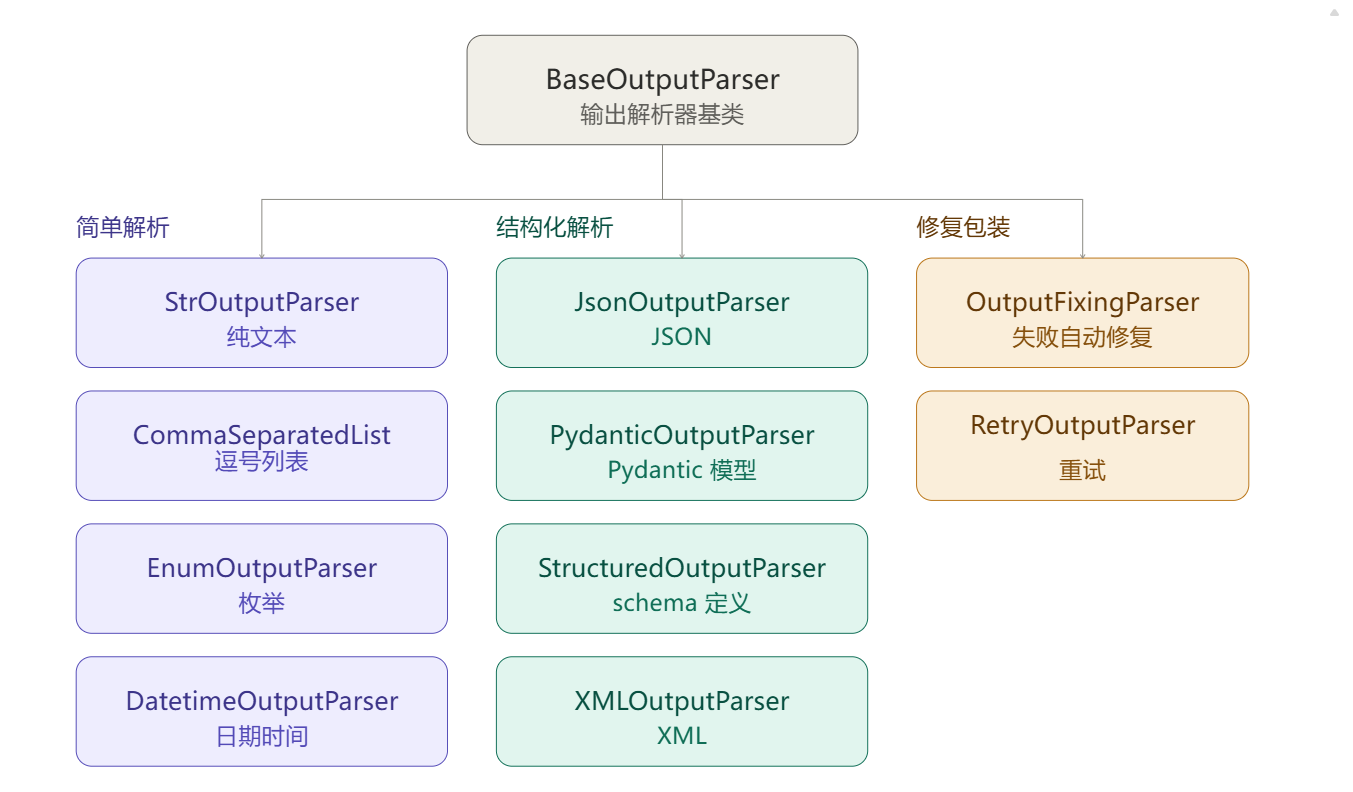

### StrOutputParser 纯文本解析

In [1]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import  StrOutputParser
model = init_chat_model(model="deepseek-flash")
prompt = ChatPromptTemplate.from_messages([
    ("system", "你是翻译助手"),
    ("human", "请把一下内容翻译成{language}：{text}")
])
output_parser = StrOutputParser()
chain = prompt | model | output_parser
res = chain.invoke({"language":"法语","text": "你好"})
print(type(res))
print(res)

<class 'langchain_core.messages.base.TextAccessor'>
Bonjour


### JsonOutputParser JSON解析

In [16]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import  JsonOutputParser
model = init_chat_model(model="deepseek-flash")
prompt = ChatPromptTemplate.from_messages([
    ("system", "你是翻译助手, 返回JSON格式，包含原文和译文"),
    ("human", "请把一下内容翻译成{language}：{text}")
])
output_parser = JsonOutputParser()
chain = prompt | model | output_parser
res = chain.invoke({"language":"法语","text": "你好"})
print(type(res))
print(res)

<class 'dict'>
{'原文': '你好', '译文': 'Bonjour'}


### CommaSeparatedListOutputParser 逗号列表、CSV解析器

In [19]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import CommaSeparatedListOutputParser
model = init_chat_model(model="deepseek-flash")
prompt = ChatPromptTemplate.from_messages([
    ("system", "你是翻译助手, 返回逗号分隔的列表，包含原文和译文"),
    ("human", "请把一下内容翻译成{language}：{text}")
])
output_parser = CommaSeparatedListOutputParser()
chain = prompt | model | output_parser
res = chain.invoke({"language":"法语","text": "你好"})
print(type(res))
print(res)

<class 'list'>
['你好', 'Bonjour']


### DatetimeOutputParser    日期时间

In [32]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.output_parsers import DatetimeOutputParser
model = init_chat_model(model="deepseek-flash")
output_parser = DatetimeOutputParser()
prompt = ChatPromptTemplate.from_messages([
    ("system", "回答用户问题, 返回格式{format_instructions}"),
    ("human", "问题：{question}")],
)
prompt = prompt.partial(format_instructions=output_parser.get_format_instructions())
chain = prompt | model | output_parser
res = chain.invoke({"question":"新中国成立是哪一年？"})
print(type(res))
print(res)

<class 'datetime.datetime'>
1949-10-01 00:00:00


In [34]:
print(output_parser.get_format_instructions())

Write a datetime string that matches the following pattern: '%Y-%m-%dT%H:%M:%S.%fZ'.

Examples: 2023-07-04T14:30:00.000000Z, 1999-12-31T23:59:59.999999Z, 2025-01-01T00:00:00.000000Z

Return ONLY this string, no other words!


### 自定义日期字符串解析器

In [42]:
import datetime
from langchain_core.output_parsers import BaseOutputParser

# --- 自定义日期字符串解析器 ---
#  1.要求通过提示词，规范大模型的返回结果：字符串类型的结果
#  2.将大模型返回的字符串结果，进行解析，解析成指定的格式
class DateStringParser(BaseOutputParser[str]):
    # 定义模型应该输出的字符串格式，也是默认返回的格式
    target_format: str = "%Y-%m-%d"

    # 解析：将大模型返回结果，按照要求解析成想要的格式
    def parse(self, text: str) -> str:
        """
        接收模型的原始输出字符串，将其解析、验证并返回格式化后的字符串。
        """
        stripped_text = text.strip()

        try:
            # 使用 datetime.strptime 尝试解析字符串。
            # 如果字符串不符合 self.target_format，将抛出 ValueError
            print("尝试解析字符串:", stripped_text)

            dt_object = datetime.datetime.strptime(stripped_text, self.target_format)
            return dt_object.strftime(self.target_format)

        except ValueError as e:
            # 如果解析失败，抛出 LangChain 异常以便链可以处理错误
            from langchain_core.exceptions import OutputParserException
            raise OutputParserException(
                f"模型输出的日期格式不正确。期望格式为 '{self.target_format}'，但收到了: '{stripped_text}'. 错误: {e}"
            )

    # 规范大模型的输出的格式，返回的是提示词
    def get_format_instructions(self) -> str:
        """返回给 LLM 的指令，要求它输出特定的日期格式。"""
        # 使用当前日期作为示例，指导模型输出正确的格式
        example_date = datetime.datetime.now().strftime(self.target_format)
        print("当前期望格式:", self.target_format)
        return (
            f"请严格按照以下格式输出日期：'{self.target_format}'.\n"
            f"例如: {example_date}\n"
            f"只返回日期字符串，不要包含任何其他文本、空格或标点符号！"
        )

# 实例化自定义解析器 可以在这里指定不同的日期格式
# date_parser = DateStringParser(target_format="%Y-%m-%d")
date_parser = DateStringParser(target_format="%m/%d/%Y %H:%M:%S")
# date_parser = DateStringParser(target_format="%d/%m/%Y")

In [43]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.output_parsers import DatetimeOutputParser
model = init_chat_model(model="deepseek-flash")
output_parser = DateStringParser()
prompt = ChatPromptTemplate.from_messages([
    ("system", "回答用户问题, 返回格式{format_instructions}"),
    ("human", "问题：{question}")],
)
prompt = prompt.partial(format_instructions=output_parser.get_format_instructions())
chain = prompt | model | output_parser
res = chain.invoke({"question":"新中国成立是哪一年？"})
print(type(res))
print(res)

当前期望格式: %Y-%m-%d
尝试解析字符串: 1949-10-01
<class 'str'>
1949-10-01
